In [7]:
import os
import glob
import pandas as pd
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import kagglehub
from torchvision import models

%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 8]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Working device for demo: {device}")

🚀 Working device for demo: cpu


In [8]:
# 1. Dataset Downloading
print("⏳ Checking/Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("requiemonk/sentinel12-image-pairs-segregated-by-terrain")
print("✅ Path to files:", path)

# 2. Searching for radar images (SAR)
all_s1_images = glob.glob(os.path.join(path, "**", "s1", "*.png"), recursive=True) + \
                glob.glob(os.path.join(path, "**", "s1", "*.jpg"), recursive=True)

data_pairs = []

# 3. Reliable pair collection
for s1_path in all_s1_images:
    s1_norm = os.path.normpath(s1_path)
    s1_dir, s1_name = os.path.split(s1_norm)
    
    s2_dir = os.path.join(os.path.dirname(s1_dir), "s2")
    s2_name_variant_A = s1_name.replace("_s1_", "_s2_")
    s2_path_A = os.path.join(s2_dir, s2_name_variant_A)
    s2_path_B = os.path.join(s2_dir, s1_name)
    
    final_s2_path = None
    if os.path.exists(s2_path_A):
        final_s2_path = s2_path_A
    elif os.path.exists(s2_path_B):
        final_s2_path = s2_path_B
        
    if final_s2_path:
        landscape = os.path.basename(os.path.dirname(s1_dir)) 
        core_name = f"{landscape}_{s1_name}"
        data_pairs.append({
            "image_a": s1_norm,
            "image_b": final_s2_path,
            "core_id": core_name
        })

# Creating DataFrame and limiting to 500 for a quick demo
df = pd.DataFrame(data_pairs).head(500)
print(f"📊 Successfully prepared {len(df)} valid cross-modal pairs.")

⏳ Checking/Downloading dataset from Kaggle...
✅ Path to files: C:\Users\Artem\.cache\kagglehub\datasets\requiemonk\sentinel12-image-pairs-segregated-by-terrain\versions\1
📊 Successfully prepared 500 valid cross-modal pairs.


In [9]:
class SiameseEmbeddingNet(nn.Module):
    def __init__(self):
        super(SiameseEmbeddingNet, self).__init__()
        # Using ResNet18 as a Feature Extractor
        backbone = models.resnet18(weights=None)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )
        
    def forward_once(self, x):
        output = self.feature_extractor(x)
        output = output.view(output.size(0), -1)
        output = self.fc(output)
        output = F.normalize(output, p=2, dim=1)  # L2 normalization of embeddings
        return output

    def forward(self, input_a, input_b):
        return self.forward_once(input_a), self.forward_once(input_b)

# Initialization and loading weights
model = SiameseEmbeddingNet().to(device)
weights_path = "model_weights.pth"

if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"✅ Trained weights [{weights_path}] successfully loaded into the model!")
else:
    print(f"⚠️ Weights file [{weights_path}] not found in the current directory. The model uses random initialization.")

✅ Trained weights [model_weights.pth] successfully loaded into the model!


C:\Temp\ipykernel_6520\118968618.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


In [10]:
def run_demo_matching(pair_index):
    if pair_index >= len(df):
        print(f"Index is too large. Available range: 0 to {len(df)-1}")
        return
        
    row = df.iloc[pair_index]
    
    # 1. Image reading and preprocessing
    img_a = cv2.imread(row['image_a'])
    img_b = cv2.imread(row['image_b'])
    
    img_a_rgb = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
    img_b_rgb = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)
    
    # Preparation for the neural network (size 256x256)
    t_a = cv2.resize(img_a_rgb, (256, 256)).astype(np.float32) / 255.0
    t_b = cv2.resize(img_b_rgb, (256, 256)).astype(np.float32) / 255.0
    
    tensor_a = torch.tensor(t_a.transpose(2, 0, 1)).unsqueeze(0).to(device)
    tensor_b = torch.tensor(t_b.transpose(2, 0, 1)).unsqueeze(0).to(device)
    
    # 2. Similarity computation via model
    model.eval()
    with torch.no_grad():
        emb_a = model.forward_once(tensor_a)
        emb_b = model.forward_once(tensor_b)
        similarity = torch.mm(emb_a, emb_b.t()).item()
        
    # 3. Keypoint detection using SIFT and RANSAC filtering
    gray_a = cv2.cvtColor(img_a_rgb, cv2.COLOR_RGB2GRAY)
    gray_b = cv2.cvtColor(img_b_rgb, cv2.COLOR_RGB2GRAY)
    
    sift = cv2.SIFT_create(nfeatures=1000)
    kpts_a, desc_a = sift.detectAndCompute(gray_a, None)
    kpts_b, desc_b = sift.detectAndCompute(gray_b, None)
    
    if desc_a is not None and desc_b is not None:
        bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
        matches = bf.knnMatch(desc_a, desc_b, k=2)
        
        good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
        
        if len(good_matches) > 4:
            src_pts = np.float32([kpts_a[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kpts_b[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            matches_mask = mask.ravel().tolist()
        else:
            matches_mask = None
            
        # Constructing the final matches image
        draw_params = dict(matchColor=(0, 255, 0),
                           singlePointColor=(255, 0, 0),
                           matchesMask=matches_mask,
                           flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        
        result_img = cv2.drawMatches(img_a, kpts_a, img_b, kpts_b, good_matches, None, **draw_params)
        result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
        
        # Result visualization inside the notebook
        plt.figure(figsize=(16, 9))
        plt.imshow(result_img_rgb)
        plt.title(f"Satellite Image Matching (ID: {row['core_id']})\nModel Similarity Score: {similarity:.4f} | Stable points found: {sum(matches_mask) if matches_mask else 0}")
        plt.axis('off')
        plt.show()
    else:
        print("❌ Could not find common descriptors for this pair of images.")

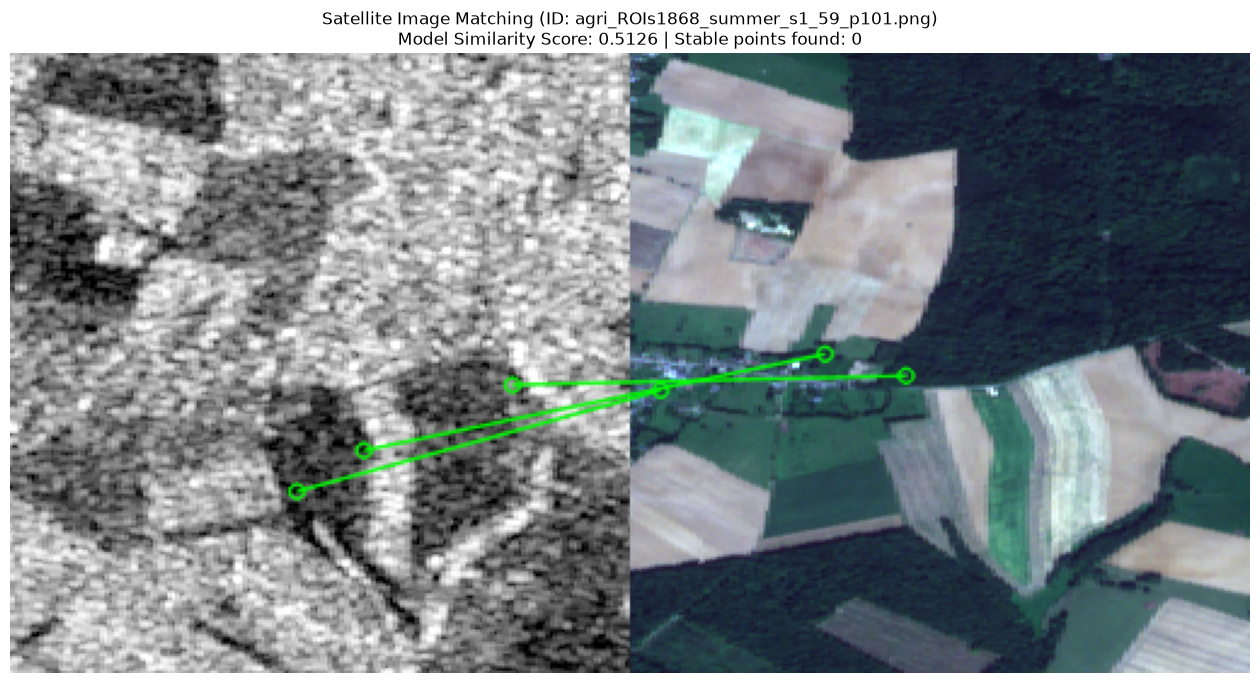

In [11]:
# Change the pair index from 0 to 499 to test different landscapes
run_demo_matching(pair_index=12)

In [ ]:
# Model weights path:

# https://drive.google.com/file/d/1jXbvJNMJGxtfLALMB-bSZ0BUEpLCaYEW/view?usp=sharing